## Links do Conteúdo

- https://github.com/wallisonferreira/data-science-tce/blob/main/PLN_Aula_04_notes.ipynb (Material Complementar)

- https://github.com/wallisonferreira/twitter-EDA/blob/main/transform/tranforming.ipynb (Limpeza de Dados)

- https://www.kaggle.com/code/halimedogan/sentiment-analysis-with-nlp-for-amazon-reviews/notebook (Usando ML + base de dados da amazon)

# Onde a NLP se encontra?

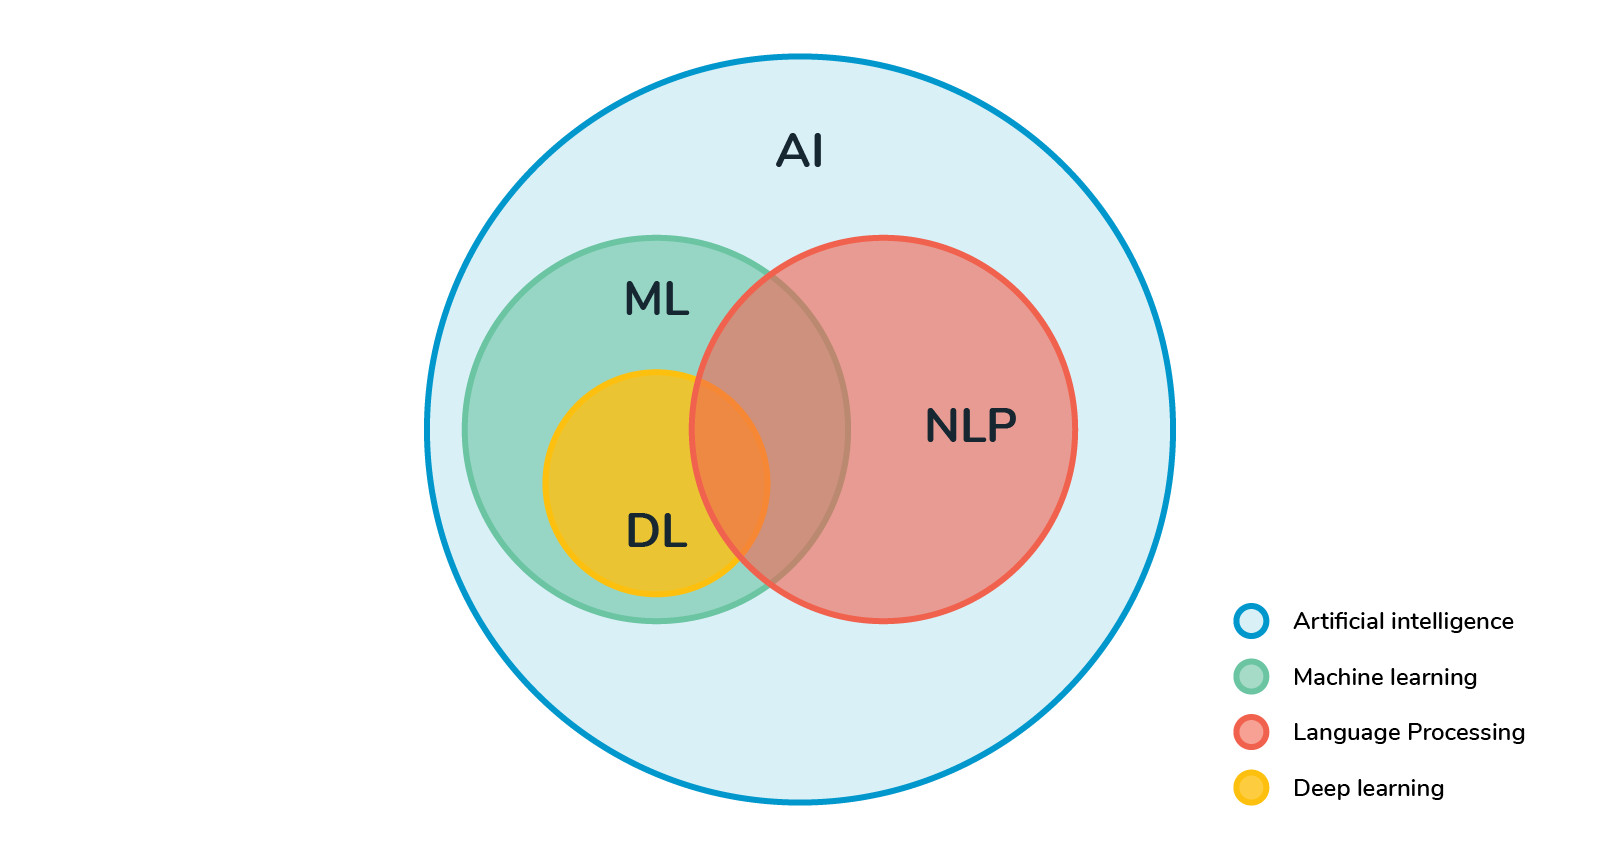

## Bibliotecas de carga

In [ ]:
import numpy as np
import pandas as pd
import requests
from io import StringIO

In [ ]:
# copia o link do google drive (precisa ser um arquivo com permissão pública)
orig_url = 'https://drive.google.com/file/d/18Imvk9CHegElwScBGjxW2txkuzLWjMET/view?usp=sharing'

# extrai o código do link do arquivo: 18Imvk9CHegElwScBGjxW2txkuzLWjMET
file_id = orig_url.split('/')[-2]

# cria um link de download do google drive
dwn_url = 'https://drive.google.com/uc?export=download&id=' + file_id

# faz o download do documento
url = requests.get(dwn_url).text

# transforma o arquivo baixado para um csv raw
csv_raw = StringIO(url)

# cria um dataframe e insere o csv nele
df = pd.read_csv(csv_raw)

In [ ]:
# visualiza os 10 primeiros registros
df.head(10)

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime,day_diff,helpful_yes,total_vote
0,A3SBTW3WS4IQSN,B007WTAJTO,NaN,"[0, 0]",No issues.,4.00,Four Stars,1406073600,2014-07-23,138,0,0
1,A18K1ODH1I2MVB,B007WTAJTO,0mie,"[0, 0]","Purchased this for my device, it worked as adv...",5.00,MOAR SPACE!!!,1382659200,2013-10-25,409,0,0
2,A2FII3I2MBMUIA,B007WTAJTO,1K3,"[0, 0]",it works as expected. I should have sprung for...,4.00,nothing to really say....,1356220800,2012-12-23,715,0,0
3,A3H99DFEG68SR,B007WTAJTO,1m2,"[0, 0]",This think has worked out great.Had a diff. br...,5.00,Great buy at this price!!! *** UPDATE,1384992000,2013-11-21,382,0,0
4,A375ZM4U047O79,B007WTAJTO,2&amp;1/2Men,"[0, 0]","Bought it with Retail Packaging, arrived legit...",5.00,best deal around,1373673600,2013-07-13,513,0,0
5,A2IDCSC6NVONIZ,B007WTAJTO,2Cents!,"[0, 0]",It's mini storage. It doesn't do anything els...,5.00,Not a lot to really be said,1367193600,2013-04-29,588,0,0
6,A26YHXZD5UFPVQ,B007WTAJTO,2K1Toaster,"[0, 0]",I have it in my phone and it never skips a bea...,5.00,Works well,1382140800,2013-10-19,415,0,0
7,A3CW0ZLUO5X2B1,B007WTAJTO,"35-year Technology Consumer ""8-tracks to 802.11""","[0, 0]",It's hard to believe how affordable digital ha...,5.00,32 GB for less than two sawbucks...what's not ...,1404950400,2014-10-07,62,0,0
8,A2CYJO155QP33S,B007WTAJTO,4evryoung,"[1, 1]",Works in a HTC Rezound. Was running short of ...,5.00,Loads of room,1395619200,2014-03-24,259,1,1
9,A2S7XG3ZC4VGOQ,B007WTAJTO,53rdcard,"[0, 0]","in my galaxy s4, super fast card, and am total...",5.00,works great,1381449600,2013-11-10,393,0,0


## Instalação de Léxicos

In [ ]:
# !pip install textblob
# !pip install wordcloud
# !pip install nltk

In [ ]:
from warnings import filterwarnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

# Bibliotecas de NLP
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer

# Bibliotecas de Aprendizado de Máquina
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, GridSearchCV, cross_validate
from sklearn.preprocessing import LabelEncoder
from textblob import Word, TextBlob
from wordcloud import WordCloud


filterwarnings('ignore')
pd.set_option('display.max_columns', None)
#pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4915 entries, 0 to 4914
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   reviewerID      4915 non-null   object 
 1   asin            4915 non-null   object 
 2   reviewerName    4914 non-null   object 
 3   helpful         4915 non-null   object 
 4   reviewText      4914 non-null   object 
 5   overall         4915 non-null   float64
 6   summary         4915 non-null   object 
 7   unixReviewTime  4915 non-null   int64  
 8   reviewTime      4915 non-null   object 
 9   day_diff        4915 non-null   int64  
 10  helpful_yes     4915 non-null   int64  
 11  total_vote      4915 non-null   int64  
dtypes: float64(1), int64(4), object(7)
memory usage: 460.9+ KB


# Processamento de Texto

In [ ]:
df.reviewText[1], df.overall[1]

('Purchased this for my device, it worked as advertised. You can never have too much phone memory, since I download a lot of stuff this was a no brainer for me.',
 5.0)

In [ ]:
df.reviewText[1], df.overall[1]

('Purchased this for my device, it worked as advertised. You can never have too much phone memory, since I download a lot of stuff this was a no brainer for me.',
 5.0)

In [ ]:
df.reviewText[11], df.overall[11]

("It works, but file writes are a bit slower than expected on a USB3 reader.Also, both reads and writes are FASTER with the card inside the standard-size SD adapter (15 MB/s vs 10 write; 45 MB/s vs 22 MB/s read) on the same card reader.  Can't figure why...",
 3.0)

In [ ]:
df[df['overall'] < 4.0]

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime,day_diff,helpful_yes,total_vote
11,A2Q3ICGWZLY3JJ,B007WTAJTO,98020,"[0, 0]","It works, but file writes are a bit slower tha...",3.00,"It works, but not as fast as expected",1384905600,2013-11-20,383,0,0
32,AF24M1HKIZ7QC,B007WTAJTO,"Abdulrahman J. Alrashed ""dr34m3r""","[0, 0]","I bought 2 of those SanDisk 32 GB microSD , us...",1.00,Bought 2 :) Died,1375488000,2013-03-08,640,0,0
38,A1FKE13D77L3Y3,B007WTAJTO,Abraham Arturo Meza Marin,"[0, 0]",I bougth this micro SD card after some trubles...,1.00,Stop working after 1 year,1361232000,2013-02-19,657,0,0
43,A1X1FX3NSOFCT3,B007WTAJTO,"Abused Commuter ""abused_commuter""","[0, 1]",Ordered this for a Galaxy S3. Lasted a few mo...,1.00,Beware... goes bad and takes your pics with it,1374278400,2013-07-20,506,0,1
49,A2RJ7DAL63MN1F,B007WTAJTO,Ace of Sevens,"[0, 0]","I used this for a few months in my phone, then...",2.00,Worked for a few months,1391126400,2014-01-31,311,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4891,A3DJS9HZ1FPANU,B007WTAJTO,Zach S.,"[1, 1]",This was the fastest microSD card I have teste...,1.00,Fast but short-lived,1363910400,2013-03-22,626,1,1
4892,A2SVI2JSSMA3PS,B007WTAJTO,Zackariah Zielieke,"[0, 1]","Hello,Great card, great price. Plenty of speed...",1.00,It worked good until return policy was out,1388016000,2013-12-26,347,0,1
4899,A3P86Z2D81VLYV,B007WTAJTO,"Zeality ""N2iT""","[0, 0]",I really don't know what to think about this I...,3.00,It didn't help my problems much very little if...,1396137600,2014-03-30,253,0,0
4904,A176OYR7KGC1PC,B007WTAJTO,zhengziying,"[1, 2]",DO NOT PUT ANY IMPORTANT DATA IN IT. DO NOT US...,1.00,failed in 1.5 months,1354665600,2012-05-12,940,1,2


## Normalização de Texto

In [ ]:
# Normalizing Case Folding
df['reviewText'] = df['reviewText'].str.lower()

# Punctuations
df['reviewText'] = df['reviewText'].str.replace('[^\w\s]', '')

# Numbers
df['reviewText'] = df['reviewText'].str.replace('\d', '')

In [ ]:
# visualiza o texto após normalização
df['reviewText']

0                                               no issues
1       purchased this for my device it worked as adve...
2       it works as expected i should have sprung for ...
3       this think has worked out greathad a diff bran...
4       bought it with retail packaging arrived legit ...
                              ...                        
4910    i bought this sandisk gb class  to use with my...
4911    used this for extending the capabilities of my...
4912    great card that is very fast and reliable it c...
4913    good amount of space for the stuff i want to d...
4914    ive heard bad things about this gb micro sd ca...
Name: reviewText, Length: 4915, dtype: object

## Remoção de Stopwords

In [ ]:
# Stopwords
import nltk

nltk.download('stopwords')

sw = stopwords.words('english')

df['reviewText'] = df['reviewText'].apply(lambda x: " ".join(x for x in str(x).split() if x not in sw))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
len(nltk.corpus.stopwords.words())

10405

In [ ]:
# visualiza o texto após remoção de stopwords
df['reviewText']

0                                                  issues
1       purchased device worked advertised never much ...
2       works expected sprung higher capacity think ma...
3       think worked greathad diff bran gb card went s...
4       bought retail packaging arrived legit orange e...
                              ...                        
4910    bought sandisk gb class use htc inspire months...
4911    used extending capabilities samsung galaxy not...
4912    great card fast reliable comes optional adapte...
4913          good amount space stuff want fits gopro say
4914    ive heard bad things gb micro sd card crapping...
Name: reviewText, Length: 4915, dtype: object

## Remoção de Palavras Raras

In [ ]:
# Rarewords

contaDocumentosAntes = len(df['reviewText'])

drops = pd.Series(' '.join(df['reviewText']).split()).value_counts()[-1000:]

df['reviewText'] = df['reviewText'].apply(lambda x: " ".join(x for x in x.split() if x not in drops))

# Continuação - Aula 29/02

## Tokenização

In [ ]:
# Tokenization

nltk.download("punkt")
df["reviewText"].apply(lambda x: TextBlob(x).words).head()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


0                                             [issues]
1    [purchased, device, worked, advertised, never,...
2    [works, expected, sprung, higher, capacity, th...
3    [think, worked, greathad, diff, bran, gb, card...
4    [bought, retail, packaging, arrived, legit, or...
Name: reviewText, dtype: object

## Lematização

In [ ]:
# Lemmatization

nltk.download('wordnet')
df['reviewText'] = df['reviewText'].apply(lambda x: " ".join([Word(word).lemmatize() for word in x.split()]))

df['reviewText'].head(10)

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


0                                                issue
1    purchased device worked advertised never much ...
2    work expected sprung higher capacity think mad...
3    think worked greathad diff bran gb card went s...
4    bought retail packaging arrived legit orange e...
5    mini storage doesnt anything else supposed pur...
6    phone never skip beat file transfer speedy cor...
7    hard believe affordable digital become gb devi...
8    work htc rezound running short space gb sandis...
9    galaxy super fast card totally happy happy sti...
Name: reviewText, dtype: object

## Visualização do Texto

In [ ]:
# Quantidade de palavras/termos em toda a coleção

tf = df["reviewText"].apply(lambda x: pd.value_counts(x.split(" "))).sum(axis=0).reset_index()

tf.columns = ["words", "tf"]
tf.head()

,words,tf
0,issues,450.00
1,purchased,344.00
2,device,330.00
3,worked,460.00
4,advertised,111.00


In [ ]:
tf.shape

(8073, 2)

In [ ]:
tf["tf"].describe([0.05, 0.10, 0.25, 0.50, 0.75, 0.80, 0.90, 0.95, 0.99]).T

count   8073.00
mean      15.33
std       96.17
min        1.00
5%         1.00
10%        1.00
25%        1.00
50%        1.00
75%        4.00
80%        7.00
90%       20.00
95%       53.00
99%      262.56
max     5537.00
Name: tf, dtype: float64

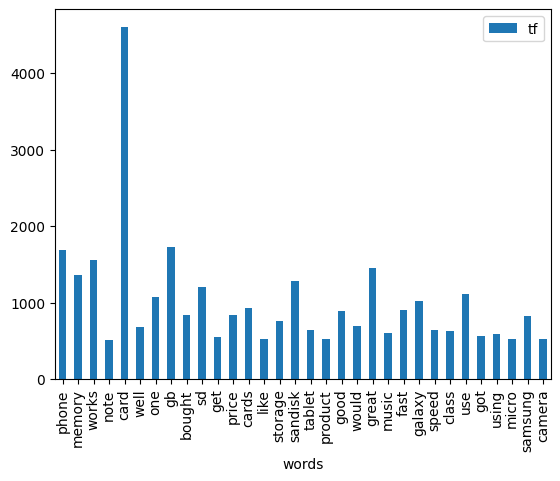

In [ ]:
# Barplot

tf[tf["tf"] > 500].plot.bar(x="words", y="tf")
plt.show()

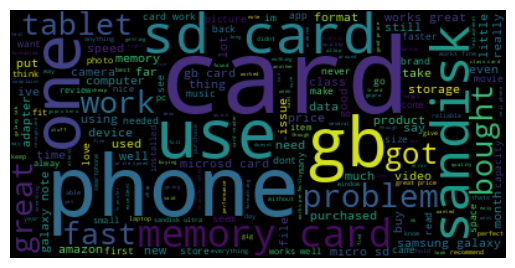

In [ ]:
# Wordcloud

text = " ".join(i for i in df.reviewText)
wordcloud = WordCloud().generate(text)
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

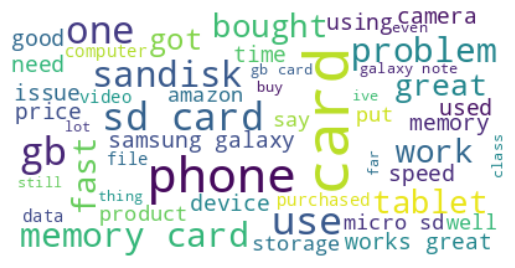

In [ ]:
wordcloud = WordCloud(max_font_size=50,
                      max_words=50,
                      background_color="white").generate(text)
plt.figure()
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

wordcloud.to_file("wordcloud.png")

# Análise de Sentimentos

In [ ]:
# NLTK already has a built-in, pretrained sentiment analyzer
# called VADER (Valence Aware Dictionary and sEntiment Reasoner).

df.head()

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime,day_diff,helpful_yes,total_vote
0,A3SBTW3WS4IQSN,B007WTAJTO,NaN,"[0, 0]",issue,4.00,Four Stars,1406073600,2014-07-23,138,0,0
1,A18K1ODH1I2MVB,B007WTAJTO,0mie,"[0, 0]",purchased device worked advertised never much ...,5.00,MOAR SPACE!!!,1382659200,2013-10-25,409,0,0
2,A2FII3I2MBMUIA,B007WTAJTO,1K3,"[0, 0]",work expected sprung higher capacity think mad...,4.00,nothing to really say....,1356220800,2012-12-23,715,0,0
3,A3H99DFEG68SR,B007WTAJTO,1m2,"[0, 0]",think worked greathad diff bran gb card went s...,5.00,Great buy at this price!!! *** UPDATE,1384992000,2013-11-21,382,0,0
4,A375ZM4U047O79,B007WTAJTO,2&amp;1/2Men,"[0, 0]",bought retail packaging arrived legit orange e...,5.00,best deal around,1373673600,2013-07-13,513,0,0


In [ ]:
nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [ ]:
sia.polarity_scores("There were so many ingredients that there was even a cockroach inside.")

{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}

In [ ]:
sia.polarity_scores("Good Person. Good Restaurant")

{'neg': 0.0, 'neu': 0.256, 'pos': 0.744, 'compound': 0.7003}

In [ ]:
df["reviewText"][0:10].apply(lambda x: sia.polarity_scores(x))[7]

{'neg': 0.066, 'neu': 0.703, 'pos': 0.231, 'compound': 0.8221}

In [ ]:
df["reviewText"][0:10].apply(lambda x: sia.polarity_scores(x)["compound"])

0   0.00
1   0.00
2   0.40
3   0.65
4   0.86
5   0.00
6   0.90
7   0.82
8   0.00
9   0.92
Name: reviewText, dtype: float64

## Cria a coluna de Polaridade usando o Score Composto

In [ ]:
df["polarity_score"] = df["reviewText"].apply(lambda x: sia.polarity_scores(x)["compound"])
df.head()

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime,day_diff,helpful_yes,total_vote,polarity_score
0,A3SBTW3WS4IQSN,B007WTAJTO,NaN,"[0, 0]",issue,4.00,Four Stars,1406073600,2014-07-23,138,0,0,0.00
1,A18K1ODH1I2MVB,B007WTAJTO,0mie,"[0, 0]",purchased device worked advertised never much ...,5.00,MOAR SPACE!!!,1382659200,2013-10-25,409,0,0,0.00
2,A2FII3I2MBMUIA,B007WTAJTO,1K3,"[0, 0]",work expected sprung higher capacity think mad...,4.00,nothing to really say....,1356220800,2012-12-23,715,0,0,0.40
3,A3H99DFEG68SR,B007WTAJTO,1m2,"[0, 0]",think worked greathad diff bran gb card went s...,5.00,Great buy at this price!!! *** UPDATE,1384992000,2013-11-21,382,0,0,0.65
4,A375ZM4U047O79,B007WTAJTO,2&amp;1/2Men,"[0, 0]",bought retail packaging arrived legit orange e...,5.00,best deal around,1373673600,2013-07-13,513,0,0,0.86


## A partir do Score Composto, criar a coluna de Sentimento

In [ ]:
df["sentiment_label"] = df["reviewText"].apply(lambda x: "pos" if sia.polarity_scores(x)["compound"] > 0 else "neg")
df.head()

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime,day_diff,helpful_yes,total_vote,sentiment_label
0,A3SBTW3WS4IQSN,B007WTAJTO,NaN,"[0, 0]",issues,4.00,Four Stars,1406073600,2014-07-23,138,0,0,neg
1,A18K1ODH1I2MVB,B007WTAJTO,0mie,"[0, 0]",purchased device worked advertised never much ...,5.00,MOAR SPACE!!!,1382659200,2013-10-25,409,0,0,neg
2,A2FII3I2MBMUIA,B007WTAJTO,1K3,"[0, 0]",works expected sprung higher capacity think ma...,4.00,nothing to really say....,1356220800,2012-12-23,715,0,0,pos
3,A3H99DFEG68SR,B007WTAJTO,1m2,"[0, 0]",think worked greathad diff bran gb card went s...,5.00,Great buy at this price!!! *** UPDATE,1384992000,2013-11-21,382,0,0,pos
4,A375ZM4U047O79,B007WTAJTO,2&amp;1/2Men,"[0, 0]",bought retail packaging arrived legit orange e...,5.00,best deal around,1373673600,2013-07-13,513,0,0,pos


## Agrupa os sentimentos

In [ ]:
df["sentiment_label"].value_counts()

pos    3927
neg     988
Name: sentiment_label, dtype: int64

## Agrupa os sentimentos e seleciona a média da classificação geral

In [ ]:
df.groupby("sentiment_label")["overall"].mean()

sentiment_label
neg   4.10
pos   4.71
Name: overall, dtype: float64

## Aplica o LabelEncoder nos sentimentos

In [ ]:
# df["sentiment_label"] = LabelEncoder().fit_transform(df["sentiment_label"])

X = df["reviewText"]
y = df["sentiment_label"]

In [ ]:
df.head()

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime,day_diff,helpful_yes,total_vote,sentiment_label
0,A3SBTW3WS4IQSN,B007WTAJTO,NaN,"[0, 0]",issues,4.00,Four Stars,1406073600,2014-07-23,138,0,0,neg
1,A18K1ODH1I2MVB,B007WTAJTO,0mie,"[0, 0]",purchased device worked advertised never much ...,5.00,MOAR SPACE!!!,1382659200,2013-10-25,409,0,0,neg
2,A2FII3I2MBMUIA,B007WTAJTO,1K3,"[0, 0]",works expected sprung higher capacity think ma...,4.00,nothing to really say....,1356220800,2012-12-23,715,0,0,pos
3,A3H99DFEG68SR,B007WTAJTO,1m2,"[0, 0]",think worked greathad diff bran gb card went s...,5.00,Great buy at this price!!! *** UPDATE,1384992000,2013-11-21,382,0,0,pos
4,A375ZM4U047O79,B007WTAJTO,2&amp;1/2Men,"[0, 0]",bought retail packaging arrived legit orange e...,5.00,best deal around,1373673600,2013-07-13,513,0,0,pos


In [ ]:
np.array(X), "-----------------",  np.array(y)

(array(['issues',
        'purchased device worked advertised never much phone memory since download lot stuff brainer',
        'works expected sprung higher capacity think made bit cheesier earlier versions paint looks clean',
        ...,
        'great card fast reliable comes optional adapter sd slots class card transfers data really fast video must great gopros small cameras alike',
        'good amount space stuff want fits gopro say',
        'ive heard bad things gb micro sd card crapping weeks sk far good transfer speeds normal like space price recommend'],
       dtype=object),
 '-----------------',
 array(['neg', 'neg', 'pos', ..., 'pos', 'pos', 'pos'], dtype=object))

In [ ]:
# ngram
a = """A análise de sentimentos é uma aplicação de tecnologias de processamento de linguagem natural
que treinam softwares de computador para entender o texto de maneiras semelhantes aos humanos."""

TextBlob(a).ngrams(5)

[WordList(['A', 'análise', 'de', 'sentimentos', 'é']),
 WordList(['análise', 'de', 'sentimentos', 'é', 'uma']),
 WordList(['de', 'sentimentos', 'é', 'uma', 'aplicação']),
 WordList(['sentimentos', 'é', 'uma', 'aplicação', 'de']),
 WordList(['é', 'uma', 'aplicação', 'de', 'tecnologias']),
 WordList(['uma', 'aplicação', 'de', 'tecnologias', 'de']),
 WordList(['aplicação', 'de', 'tecnologias', 'de', 'processamento']),
 WordList(['de', 'tecnologias', 'de', 'processamento', 'de']),
 WordList(['tecnologias', 'de', 'processamento', 'de', 'linguagem']),
 WordList(['de', 'processamento', 'de', 'linguagem', 'natural']),
 WordList(['processamento', 'de', 'linguagem', 'natural', 'que']),
 WordList(['de', 'linguagem', 'natural', 'que', 'treinam']),
 WordList(['linguagem', 'natural', 'que', 'treinam', 'softwares']),
 WordList(['natural', 'que', 'treinam', 'softwares', 'de']),
 WordList(['que', 'treinam', 'softwares', 'de', 'computador']),
 WordList(['treinam', 'softwares', 'de', 'computador', 'para'

# Conta a presença de termos com Count Vectorizer

In [ ]:
# Count Vectors

from sklearn.feature_extraction.text import CountVectorizer

corpus = ['This is the first document.',
          'This document is the second document.',
          'And this is the third one.',
          'Is this the first document?']

In [ ]:
# word
vectorizer = CountVectorizer()
X_c = vectorizer.fit_transform(corpus)
vectorizer.get_feature_names_out()
X_c.toarray()

array([[0, 1, 1, 1, 0, 0, 1, 0, 1],
       [0, 2, 0, 1, 0, 1, 1, 0, 1],
       [1, 0, 0, 1, 1, 0, 1, 1, 1],
       [0, 1, 1, 1, 0, 0, 1, 0, 1]])

In [ ]:
vectorizer.get_feature_names_out()

array(['and', 'document', 'first', 'is', 'one', 'second', 'the', 'third',
       'this'], dtype=object)

## Count vectorizer com N-grams

In [ ]:
# n-gram
vectorizer2 = CountVectorizer(analyzer='word', ngram_range=(2, 2))
X_n = vectorizer2.fit_transform(corpus)
vectorizer2.get_feature_names_out()
X_n.toarray()

array([[0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0],
       [0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0],
       [1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0],
       [0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1]])

In [ ]:
vectorizer = CountVectorizer()
X_count = vectorizer.fit_transform(X)

print(vectorizer.get_feature_names_out()[10:15])
print(X_count.toarray()[10:15])

['absolutely' 'abt' 'abuse' 'abysmal' 'accdientally']
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


## Importância dos termos com TF-IDF

In [ ]:
# word tf-idf
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(analyzer='word')
X_w = vectorizer.fit_transform(corpus)
vectorizer.get_feature_names_out()
X_w.toarray()

array([[0.        , 0.46979139, 0.58028582, 0.38408524, 0.        ,
        0.        , 0.38408524, 0.        , 0.38408524],
       [0.        , 0.6876236 , 0.        , 0.28108867, 0.        ,
        0.53864762, 0.28108867, 0.        , 0.28108867],
       [0.51184851, 0.        , 0.        , 0.26710379, 0.51184851,
        0.        , 0.26710379, 0.51184851, 0.26710379],
       [0.        , 0.46979139, 0.58028582, 0.38408524, 0.        ,
        0.        , 0.38408524, 0.        , 0.38408524]])

Importância dos termos com TF-IDF + N-GRAMS

In [ ]:
# n-gram tf-idf
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(ngram_range=(2, 3))
X_n = vectorizer.fit_transform(corpus)
vectorizer.get_feature_names_out()
X_n.toarray()

array([[0.        , 0.        , 0.        , 0.        , 0.37102749,
        0.30037873, 0.47060133, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.37102749, 0.37102749, 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.37102749, 0.37102749, 0.        , 0.        ],
       [0.        , 0.        , 0.34488069, 0.34488069, 0.        ,
        0.22013288, 0.        , 0.34488069, 0.        , 0.        ,
        0.        , 0.34488069, 0.        , 0.        , 0.34488069,
        0.34488069, 0.        , 0.        , 0.        , 0.34488069,
        0.34488069, 0.        , 0.        , 0.        , 0.        ],
       [0.36153669, 0.36153669, 0.        , 0.        , 0.        ,
        0.23076418, 0.        , 0.        , 0.36153669, 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.36153669, 0.36153669, 0.36153669, 0.        ,
        0.        , 0.28503968, 0.28503968, 0.

## Vetorização dos Termos com TF-IDF

In [ ]:
tf_idf_word_vectorizer = TfidfVectorizer()
X_tf_idf_word = tf_idf_word_vectorizer.fit_transform(X)

In [ ]:
X_tf_idf_word

  (0, 3803)	1.0
  (1, 781)	0.4658738086207278
  (1, 7300)	0.31970032458392156
  (1, 4236)	0.2528019059508647
  (1, 2050)	0.35157408953830543
  (1, 6851)	0.2634357737241613
  (1, 4468)	0.1634326468502743
  (1, 5355)	0.1589531359558262
  (1, 4710)	0.22880539197103422
  (1, 4813)	0.23747156346555395
  (1, 129)	0.30795033953443185
  (1, 8516)	0.22041661146411293
  (1, 1864)	0.25009741320863493
  (1, 5846)	0.2390714438794639
  (2, 1231)	0.33398167091639896
  (2, 4214)	0.2528471854235855
  (2, 5190)	0.3434263073935642
  (2, 8198)	0.27127218991399876
  (2, 2147)	0.3046439503907338
  (2, 1177)	0.3727640279192294
  (2, 663)	0.21164557661110028
  (2, 4282)	0.21071531094623208
  (2, 7633)	0.18946407666520712
  (2, 964)	0.17084296965913953
  (2, 3379)	0.2470400952821832
  :	:
  (4913, 2730)	0.4263358215484231
  (4913, 7041)	0.2880654734074288
  (4913, 8288)	0.3663845215144315
  (4913, 3101)	0.2353159000908284
  (4913, 7300)	0.4143611722377741
  (4914, 6877)	0.41819957554755244
  (4914, 1596)	0.398

# Modelagem

## 1. Regressão Logística

In [ ]:
# Cria o modelo Logistic Regression
log_model = LogisticRegression().fit(X_tf_idf_word, y)

# validação cruzada
cross_val_score(log_model,
                X_tf_idf_word,
                y, scoring="accuracy",
                cv=5).mean()

# escolhe o texto a ser classifado
#texto1 = pd.Series("this product is great")
#texto2 = pd.Series("look at that shit very bad")
texto3 = pd.Series("it was good but I am sure that it fits me")

serie = CountVectorizer().fit(X).transform(texto3)

# classificação do texto
log_model.predict(serie)

array(['pos'], dtype=object)

### Acurácia do modelo

In [ ]:
cross_val_score(log_model,
                X_tf_idf_word,
                y, scoring="accuracy",
                cv=5).mean()

0.8211597151576806

### Seleciona uma revisão aleatoriamente

In [ ]:
random_review = pd.Series(df["reviewText"].sample(1).values)

print(random_review)
print(log_model.predict(serie))

0    got use cobra dashcam cam came card small seem...
dtype: object
['pos']


## 2. Modelo Random Forest

In [ ]:
# Count Vectors
rf_model = RandomForestClassifier().fit(X_count, y)
cross_val_score(rf_model, X_count, y, cv=5, n_jobs=-1).mean()

0.8321464903357072

In [ ]:
# TF-IDF Word-Level
rf_model = RandomForestClassifier().fit(X_tf_idf_word, y)
cross_val_score(rf_model, X_tf_idf_word, y, cv=5, n_jobs=-1).mean()

0.8213631739572737

### Fazendo uma busca de melhores parâmetros do Random Forest com Grid Search

In [ ]:
rf_model = RandomForestClassifier(random_state=17)

rf_params = {"max_depth": [5, 8, None],
             "max_features": [5, 7, "auto"],
             "min_samples_split": [2, 3, 10],
             "n_estimators": [0, 3, 100]}

rf_best_grid = GridSearchCV(rf_model,
                            rf_params,
                            cv=5,
                            n_jobs=-1,
                            verbose=True).fit(X_count, y)

rf_best_grid.best_params_

rf_final = rf_model.set_params(**rf_best_grid.best_params_, random_state=17).fit(X_count, y)

cv_results = cross_validate(rf_final, X_count, y, cv=3, scoring=["accuracy", "f1", "roc_auc"])

Fitting 5 folds for each of 81 candidates, totalling 405 fits


### Visualizando os melhores parâmetros encontrados

In [ ]:
rf_best_grid.best_params_

{'max_depth': None,
 'max_features': 'auto',
 'min_samples_split': 2,
 'n_estimators': 100}

In [ ]:
rf_final = rf_model.set_params(**rf_best_grid.best_params_, random_state=17).fit(X_count, y)

In [ ]:
cv_results = cross_validate(rf_final, X_count, y, cv=3, scoring=["accuracy", "f1", "roc_auc"])

# Tarefa

1) Altere os parâmetros do modelo Forest

2) Faça uma busca do melhor modelo usando Grid Search

3) Altere o Tf-IDF para

In [ ]:
df.columns

Index(['reviewerID', 'asin', 'reviewerName', 'helpful', 'reviewText',
       'overall', 'summary', 'unixReviewTime', 'reviewTime', 'day_diff',
       'helpful_yes', 'total_vote', 'sentiment_label'],
      dtype='object')

In [ ]:
df.head()

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime,day_diff,helpful_yes,total_vote,sentiment_label
0,A3SBTW3WS4IQSN,B007WTAJTO,NaN,"[0, 0]",issues,4.00,Four Stars,1406073600,2014-07-23,138,0,0,neg
1,A18K1ODH1I2MVB,B007WTAJTO,0mie,"[0, 0]",purchased device worked advertised never much ...,5.00,MOAR SPACE!!!,1382659200,2013-10-25,409,0,0,neg
2,A2FII3I2MBMUIA,B007WTAJTO,1K3,"[0, 0]",works expected sprung higher capacity think ma...,4.00,nothing to really say....,1356220800,2012-12-23,715,0,0,pos
3,A3H99DFEG68SR,B007WTAJTO,1m2,"[0, 0]",think worked greathad diff bran gb card went s...,5.00,Great buy at this price!!! *** UPDATE,1384992000,2013-11-21,382,0,0,pos
4,A375ZM4U047O79,B007WTAJTO,2&amp;1/2Men,"[0, 0]",bought retail packaging arrived legit orange e...,5.00,best deal around,1373673600,2013-07-13,513,0,0,pos
